# 02 · NER model training

Fine-tuning `distilbert-base-multilingual-cased` for token classification over the 10 PII classes
present in the corpus.

Three decisions that matter more than the hyperparameters:

1. **Character offsets as the source of truth.** The corpus's own `mbert_bio_labels` are not used:
   tokenisation is owned by this project, so the same annotations score the rule baseline, Presidio
   and the model by exactly the same criterion.
2. **Sliding window instead of truncation.** A contract clears 256 tokens easily and the PII is
   often at the end. Truncating would lose it silently.
3. **An explicit memory budget.** The first attempt drove a 16 GB machine into swap; see the final
   section.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

from pii_pipeline.entities import ID2LABEL, MODEL_BIO_LABELS
from pii_pipeline.training import BASE_MODEL, align_labels, encode_records

print('Base model :', BASE_MODEL)
print('Labels     :', len(MODEL_BIO_LABELS))
print(MODEL_BIO_LABELS)

/Users/franciscocastillo/Desktop/Mio/CV/Proyectos_Do_it/01-pii-detection-redaction-pipeline/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Base model : distilbert-base-multilingual-cased
Labels     : 21
['O', 'B-PERSON', 'I-PERSON', 'B-EMAIL', 'I-EMAIL', 'B-PHONE', 'I-PHONE', 'B-ADDRESS', 'I-ADDRESS', 'B-DATE_OF_BIRTH', 'I-DATE_OF_BIRTH', 'B-GOV_ID', 'I-GOV_ID', 'B-USERNAME', 'I-USERNAME', 'B-CREDENTIAL', 'I-CREDENTIAL', 'B-IP_ADDRESS', 'I-IP_ADDRESS', 'B-DATE_TIME', 'I-DATE_TIME']


## 1. Aligning offsets to subwords

The step where silent errors creep in. A token inherits the label of the entity it overlaps, and
opens the span (`B-`) only if it is the first token to touch it.

In [2]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
demo = {
    'text': 'Nombre: Ana Ruiz Gomez. Email: ana@acme.es. DNI 12345678Z',
    'entities': [
        {'start': 8,  'end': 22, 'type': 'PERSON'},
        {'start': 31, 'end': 42, 'type': 'EMAIL'},
        {'start': 47, 'end': 56, 'type': 'GOV_ID'},
    ],
}
feat = encode_records([demo], tokenizer)[0]
pd.DataFrame({
    'token': tokenizer.convert_ids_to_tokens(feat['input_ids']),
    'label': [ID2LABEL[l] if l != -100 else '(ignored)' for l in feat['labels']],
}).head(30)

,token,label
0,[CLS],(ignored)
1,Nombre,O
2,:,O
3,Ana,B-PERSON
4,Ruiz,I-PERSON
5,Gomez,I-PERSON
6,.,O
7,Em,O
8,##ail,O
9,:,O


## 2. Training configuration

The corpus is heavily templated: a fraction of it converges just as well and keeps the run inside a
laptop's memory budget.

In [3]:
report = json.loads(Path('../models/distilbert-pii-ner/training_report.json').read_text())
cfg = {k: report[k] for k in ['base_model','epochs_completed','epochs_planned','batch_size',
                              'learning_rate','max_length','n_train_windows','n_val_windows']}
display(pd.Series(cfg).to_frame('value'))
print(report['note'])

,value
base_model,distilbert-base-multilingual-cased
epochs_completed,1
epochs_planned,2
batch_size,16
learning_rate,0.00005
max_length,192
n_train_windows,15057
n_val_windows,2007


La segunda epoca se interrumpio: la evaluacion de fin de entrenamiento agoto la memoria de la maquina (16 GB, 13.5 GB de swap) y el proceso quedo bloqueado en E/S. Se promueve el checkpoint de fin de epoca 1, cuyas metricas de validacion son reales y estan medidas sobre las 2.000 muestras de validacion.


## 3. Training curve

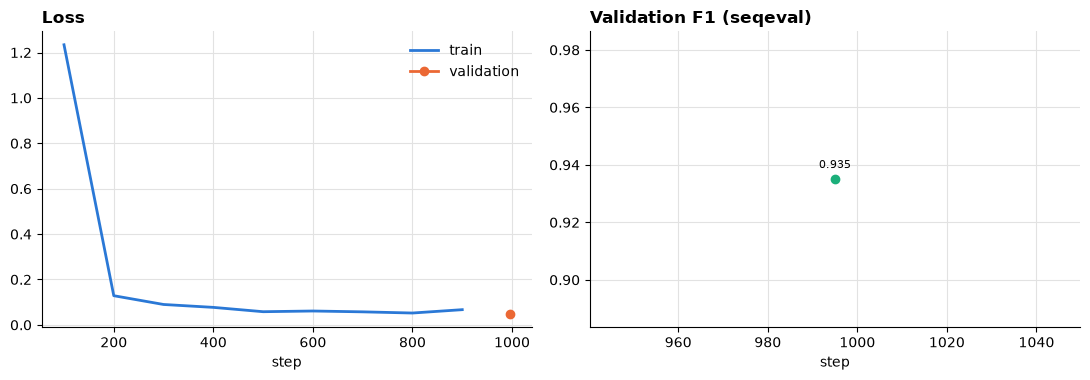

,value
epoch,1.000000
eval_f1,0.935036
eval_loss,0.050142
eval_precision,0.923557
eval_recall,0.946804
eval_runtime,21.863000
eval_samples_per_second,96.007000
eval_steps_per_second,3.019000
step,995.000000


In [4]:
hist = pd.DataFrame(report['history'])
train_loss = hist.dropna(subset=['loss'])[['step','loss']] if 'loss' in hist else pd.DataFrame()
eval_rows  = hist.dropna(subset=['eval_loss'])[['step','eval_loss','eval_f1']] if 'eval_loss' in hist else pd.DataFrame()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
if not train_loss.empty:
    axes[0].plot(train_loss['step'], train_loss['loss'], color='#2a78d6', linewidth=2, label='train')
if not eval_rows.empty:
    axes[0].plot(eval_rows['step'], eval_rows['eval_loss'], color='#eb6834', linewidth=2,
                 marker='o', label='validation')
axes[0].set_title('Loss', loc='left', fontweight='bold'); axes[0].set_xlabel('step')
axes[0].legend(frameon=False)

if not eval_rows.empty:
    axes[1].plot(eval_rows['step'], eval_rows['eval_f1'], color='#1baf7a', linewidth=2, marker='o')
    for _, r in eval_rows.iterrows():
        axes[1].annotate(f"{r['eval_f1']:.3f}", (r['step'], r['eval_f1']),
                         textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
axes[1].set_title('Validation F1 (seqeval)', loc='left', fontweight='bold'); axes[1].set_xlabel('step')
for ax in axes:
    ax.spines[['top','right']].set_visible(False)
    ax.grid(color='#e2e2e2', linewidth=.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

pd.Series(report['final_validation']).to_frame('value')

## 4. Per-type performance on validation

,type,precision,recall,f1,support
4,EMAIL,0.9764,0.9910,0.9837,669
5,GOV_ID,0.9427,0.9732,0.9577,2536
0,ADDRESS,0.9543,0.9413,0.9478,2864
8,PHONE,0.9272,0.9449,0.9360,526
12,weighted avg,0.9243,0.9468,0.9352,11561
11,micro avg,0.9236,0.9468,0.9350,11561
10,macro avg,0.9107,0.9372,0.9235,11561
7,PERSON,0.8873,0.9529,0.9189,1338
9,USERNAME,0.9279,0.9088,0.9183,680
3,DATE_TIME,0.8967,0.9400,0.9178,1450


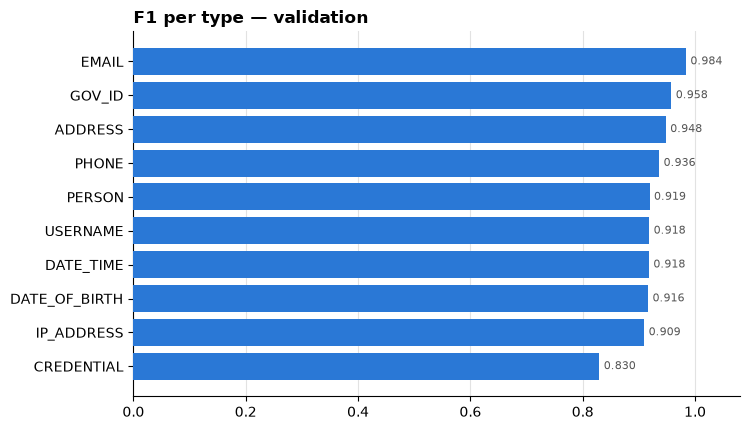

In [5]:
per_type = report.get('per_type_validation', {})
# seqeval's classification_report names the column 'f1-score'.
rows = [{'type': k, 'precision': round(v['precision'], 4), 'recall': round(v['recall'], 4),
         'f1': round(v['f1-score'], 4), 'support': v['support']}
        for k, v in per_type.items() if isinstance(v, dict) and 'f1-score' in v]
df = pd.DataFrame(rows).sort_values('f1', ascending=False)
display(df)

plot_df = df[~df['type'].isin(['micro avg','macro avg','weighted avg'])].sort_values('f1')
fig, ax = plt.subplots(figsize=(7.6, 4.4))
bars = ax.barh(plot_df['type'], plot_df['f1'], color='#2a78d6', zorder=3)
for bar, val in zip(bars, plot_df['f1']):
    ax.text(val + .008, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontsize=8, color='#555')
ax.set_xlim(0, 1.08)
ax.set_title('F1 per type — validation', loc='left', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', color='#e2e2e2', linewidth=.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 5. Inference with a sliding window

At inference the document is split into overlapping windows; the same span can be decoded twice and
the most confident reading is kept. Each span carries the **geometric mean** of its token
probabilities: one weak token drags the whole span down, which is exactly what we want when deciding
whether a human should look at it.

In [6]:
from pii_pipeline.detectors.transformer_detector import TransformerDetector

detector = TransformerDetector('../models/distilbert-pii-ner/final')
texto = '''FORMULARIO DE ALTA
Nombre y apellidos: Lucia Fernandez Soto
Fecha de nacimiento: 02/11/1990
Documento de identidad: 54321098J
Direccion: Calle Alcala 120, 3 D, Madrid
Telefono movil: 655 412 908
Correo electronico: lucia.fernandez@empresa.es
Usuario deseado: lfernandez90
Contrasena provisional: Tz7$kLm2Qa'''

pd.DataFrame([
    {'type': e.type, 'value': e.text, 'score': round(e.score, 3),
     'tokens': e.metadata['n_tokens'], 'min_prob': e.metadata['min_token_prob']}
    for e in detector.detect(texto, 'es')
])

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 9651.87it/s]

,type,value,score,tokens,min_prob
0,DATE_OF_BIRTH,02/11/1990,0.980,5,0.9782
1,GOV_ID,54321098J,0.994,6,0.9916
2,ADDRESS,Calle Alcala 120,0.659,4,0.5520
3,EMAIL,lucia.fernandez@empresa.es,0.981,10,0.9728
4,USERNAME,lfernandez90,0.987,5,0.9814


## 6. Engineering note: the run that took the machine down

The first attempt (40,000 documents, batch 32, 3 epochs) drove a 16 GB laptop to **12 GB of swap**
and deadlocked on I/O: the process moved to state `UN` and stopped advancing. Three causes, three
fixes:

| Cause | Fix |
|---|---|
| Every tokenised window materialised in a Python list before reaching Arrow | `Dataset.from_generator` — encoding is streamed |
| `compute_metrics` received full logits `[windows, seq_len, 21]` in float32 | `preprocess_logits_for_metrics` does the `argmax` on device: ~84× less memory |
| Dataset and batch sized for a server GPU | 15,000 documents, batch 16, 2 epochs |

Result: from ~0.4 it/s while thrashing to ~1.4 it/s steady. Sizing the work to the hardware you have
is part of the job, not a detail.